In [1]:
from scipy.stats import chi2, norm
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Log, CLogLog, Logit
from statsmodels.genmod.families.links import Identity
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *

In [2]:
df1 = pd.read_csv('dataset/beetles.txt', sep=' ')
print(df1.head())

     Dose  Exposed  Mortality
0  1.6907       59          6
1  1.7242       60         13
2  1.7552       62         18
3  1.7842       56         28
4  1.8113       63         52


In [3]:
df2 = pd.read_csv('dataset/beetles2.txt', sep=' ')
print(df2.head())
print(df2['Status'].value_counts())

     Dose Status
0  1.6907   Died
1  1.6907   Died
2  1.6907   Died
3  1.6907   Died
4  1.6907   Died
Status
Died        291
Survived    190
Name: count, dtype: int64


In [4]:
df2['Status'] = pd.Categorical(df2['Status'], categories=['Died', 'Survived'], ordered=True)

print(df2.info())

<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Dose    481 non-null    float64 
 1   Status  481 non-null    category
dtypes: category(1), float64(1)
memory usage: 4.5 KB
None


In [5]:
df1['fail'] = df1['Exposed'] - df1['Mortality']

fm1 = glm('Mortality + fail ~ Dose', df1, family=Binomial()).fit()
print(fm1.summary2(),'\n')

# Goodness of fit test
print(chi2.sf(fm1.deviance, fm1.df_resid))

                Results: Generalized linear model
Model:              GLM                   Method:         IRLS   
Model Family:       Binomial              AIC:            41.4303
Link Function:      Logit                 BIC:            41.5892
Dependent Variable: ['Mortality', 'fail'] Log-Likelihood: -18.715
Date:               2026-09-29 15:05      LL-Null:        -155.20
No. Observations:   8                     Deviance:       11.232 
Df Model:           1                     Pearson chi2:   10.0   
Df Residuals:       6                     Scale:          1.0000 
-----------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-----------------------------------------------------------------
Intercept     -60.7175   5.1807 -11.7199 0.0000 -70.8715 -50.5634
Dose           34.2703   2.9121  11.7681 0.0000  28.5626  39.9780
 

0.08145880992733669


In [6]:
fm2 = glm('Status ~ Dose', df2, family=Binomial()).fit()
print(fm2.summary2(),'\n')

                        Results: Generalized linear model
Model:              GLM                                  Method:         IRLS    
Model Family:       Binomial                             AIC:            376.4708
Link Function:      Logit                                BIC:            384.8225
Dependent Variable: ['Status[Died]', 'Status[Survived]'] Log-Likelihood: -186.24 
Date:               2026-09-29 15:05                     LL-Null:        -322.72 
No. Observations:   481                                  Deviance:       372.47  
Df Model:           1                                    Pearson chi2:   436.    
Df Residuals:       479                                  Scale:          1.0000  
-------------------------------------------------------------------------------------
               Coef.       Std.Err.        z         P>|z|       [0.025       0.975] 
-------------------------------------------------------------------------------------
Intercept     -60.7175      

In [7]:
fm1 = glm('Mortality + fail ~ Dose', df1, family=Binomial(link=CLogLog())).fit()
print(fm1.summary2(),'\n')

print(chi2.sf(fm1.deviance, fm1.df_resid))

                Results: Generalized linear model
Model:              GLM                   Method:         IRLS   
Model Family:       Binomial              AIC:            33.6445
Link Function:      CLogLog               BIC:            33.8034
Dependent Variable: ['Mortality', 'fail'] Log-Likelihood: -14.822
Date:               2026-09-29 15:07      LL-Null:        -155.20
No. Observations:   8                     Deviance:       3.4464 
Df Model:           1                     Pearson chi2:   3.29   
Df Residuals:       6                     Scale:          1.0000 
-----------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-----------------------------------------------------------------
Intercept     -39.5723   3.2403 -12.2126 0.0000 -45.9231 -33.2215
Dose           22.0412   1.7994  12.2495 0.0000  18.5145  25.5678
 

0.7510816172506881


In [8]:
fm2 = update_glm(fm1, add='I(Dose**2)')
print(fm2.summary2())
print(chi2.sf(fm2.deviance, fm2.df_resid),'\n')

                Results: Generalized linear model
Model:              GLM                   Method:         IRLS   
Model Family:       Binomial              AIC:            35.6087
Link Function:      CLogLog               BIC:            35.8470
Dependent Variable: ['Mortality', 'fail'] Log-Likelihood: -14.804
Date:               2026-09-29 15:08      LL-Null:        -155.20
No. Observations:   8                     Deviance:       3.4106 
Df Model:           2                     Pearson chi2:   3.26   
Df Residuals:       5                     Scale:          1.0000 
-----------------------------------------------------------------
               Coef.   Std.Err.    z    P>|z|    [0.025   0.975] 
-----------------------------------------------------------------
Intercept     -19.0178 108.1390 -0.1759 0.8604 -230.9664 192.9308
Dose           -0.9678 121.0657 -0.0080 0.9936 -238.2523 236.3166
I(Dose ** 2)    6.4349  33.8700  0.1900 0.8493  -59.9490  72.8188

0.6369528850055065 



In [9]:
fm3 = update_glm(fm2, add='I(Dose**3)')
print(fm3.summary2())
print(chi2.sf(fm3.deviance, fm3.df_resid),'\n')

                  Results: Generalized linear model
Model:                 GLM                    Method:          IRLS   
Model Family:          Binomial               AIC:             37.3434
Link Function:         CLogLog                BIC:             37.6611
Dependent Variable:    ['Mortality', 'fail']  Log-Likelihood:  -14.672
Date:                  2026-09-29 15:08       LL-Null:         -155.20
No. Observations:      8                      Deviance:        3.1453 
Df Model:              3                      Pearson chi2:    3.00   
Df Residuals:          4                      Scale:           1.0000 
----------------------------------------------------------------------
               Coef.     Std.Err.    z    P>|z|     [0.025     0.975] 
----------------------------------------------------------------------
Intercept     1740.0153 3265.4474  0.5329 0.5941  -4660.1440 8140.1747
Dose         -2960.6274 5487.1445 -0.5396 0.5895 -13715.2331 7793.9782
I(Dose ** 2)  1665.4649 3

In [10]:
print(anova_nested(fm1, fm2, fm3))

         Resid. Df  Resid. Dev   Df  Deviance  Pr(>Chi)
Model 1        6.0    3.446439  NaN       NaN       NaN
Model 2        5.0    3.410621  1.0  0.035818  0.849892
Model 3        4.0    3.145312  1.0  0.265308  0.606496


In [11]:
beta = np.array(fm1.params)

def LD(p):
    zeta = np.log(-np.log(1-p))
    return (zeta-beta[0])/beta[1]

LD50 = LD(0.5)
LD90 = LD(0.9)
print('LD50:', LD50)  
print('LD90:', LD90)  

LD50: 1.778753033557946
LD90: 1.8332213484354


In [13]:
def compute_LD_CI(model, p):
    beta = np.array(model.params)
    Sigma = model.cov_params()
    zeta = np.log(-np.log(1-p))
    h = np.array([-1/beta[1], -(zeta-beta[0])/beta[1]**2])
    sd_x = np.sqrt(h @ Sigma @ h)
    return LD(p) + np.array([-1,1]) * norm.ppf(0.975) * sd_x

LD50_CI = compute_LD_CI(fm1, 0.5)
print(LD50_CI)

LD90_CI = compute_LD_CI(fm1, 0.9)
print(LD90_CI)

[1.77090037 1.78660569]
[1.82440954 1.84203315]


In [14]:
def compute_LD_CI(x, beta):
    h = np.array([-1/beta[1], -x/beta[1]])
    sd_x = np.sqrt(h @ np.array(fm1.cov_params()) @ h)
    return x + np.array([-1,1]) * norm.ppf(0.975) * sd_x

LD50_CI = compute_LD_CI(LD50, beta)
print(LD50_CI)

LD90_CI = compute_LD_CI(LD90, beta)
print(LD90_CI)

[1.77090037 1.78660569]
[1.82440954 1.84203315]


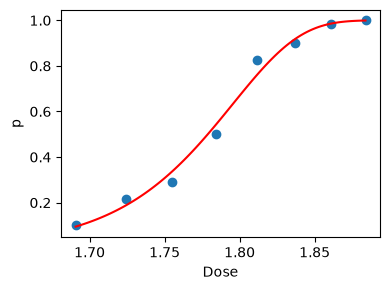

In [15]:
df1['prop'] = df1['Mortality'] / df1['Exposed']
doses = np.linspace(min(df1['Dose']), max(df1['Dose']), 100)
pred_df = pd.DataFrame({'Dose': doses})

plt.figure(figsize=(4, 3))
plt.scatter(df1['Dose'], df1['prop'])
plt.plot(doses, fm1.predict(pred_df), 'r-')
plt.xlabel('Dose')
plt.ylabel('p')
plt.tight_layout()  

plt.show()

In [16]:
fm1_logit = glm('Mortality + fail ~ Dose', df1, family=Binomial()).fit()
fm2_logit = update_glm(fm1_logit, add='I(Dose**2)')
fm3_logit = update_glm(fm2_logit, add='I(Dose**3)')

print(anova_nested(fm1_logit, fm2_logit, fm3_logit))

         Resid. Df  Resid. Dev   Df  Deviance  Pr(>Chi)
Model 1        6.0   11.232231  NaN       NaN       NaN
Model 2        5.0    3.194905  1.0  8.037326  0.004582
Model 3        4.0    2.921361  1.0  0.273544  0.600964


In [17]:
print(fm2_logit.summary2(),'\n')
print(f"Log-Likelihood: {fm2_logit.llf:.4f}")
print(f"AIC: {fm2_logit.aic:.4f}")

                Results: Generalized linear model
Model:               GLM                   Method:         IRLS   
Model Family:        Binomial              AIC:            35.3929
Link Function:       Logit                 BIC:            35.6313
Dependent Variable:  ['Mortality', 'fail'] Log-Likelihood: -14.696
Date:                2026-09-29 15:17      LL-Null:        -155.20
No. Observations:    8                     Deviance:       3.1949 
Df Model:            2                     Pearson chi2:   3.00   
Df Residuals:        5                     Scale:          1.0000 
------------------------------------------------------------------
               Coef.   Std.Err.    z    P>|z|    [0.025    0.975] 
------------------------------------------------------------------
Intercept     431.1058 180.6536  2.3864 0.0170   77.0312  785.1804
Dose         -520.6153 204.5226 -2.5455 0.0109 -921.4721 -119.7584
I(Dose ** 2)  156.4116  57.8630  2.7031 0.0069   43.0021  269.8210
 

Log-Likel

In [18]:
print(fm1.summary2(),'\n')
print(f"Log-Likelihood: {fm1.llf:.4f}")
print(f"AIC: {fm1.aic:.4f}")

                Results: Generalized linear model
Model:              GLM                   Method:         IRLS   
Model Family:       Binomial              AIC:            33.6445
Link Function:      CLogLog               BIC:            33.8034
Dependent Variable: ['Mortality', 'fail'] Log-Likelihood: -14.822
Date:               2026-09-29 15:18      LL-Null:        -155.20
No. Observations:   8                     Deviance:       3.4464 
Df Model:           1                     Pearson chi2:   3.29   
Df Residuals:       6                     Scale:          1.0000 
-----------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-----------------------------------------------------------------
Intercept     -39.5723   3.2403 -12.2126 0.0000 -45.9231 -33.2215
Dose           22.0412   1.7994  12.2495 0.0000  18.5145  25.5678
 

Log-Likelihood: -14.8222
AIC: 33.6445
